In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense

In [3]:
df=pd.read_csv('goog.csv')

In [4]:
data=df[['Open']].values

In [5]:
#Normalize
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(data)

In [6]:
#time-series sequences
x=[]
y=[]
time_step=10

for i in range(time_step,len(scaled_data)):
  x.append(scaled_data[i-time_step:i,0])
  y.append(scaled_data[i,0])

x=np.array(x)
y=np.array(y)

In [7]:
x=np.reshape(x,(x.shape[0],x.shape[1],1))
print(x.shape)

(51, 10, 1)


In [14]:
model= Sequential()
#first RNN layer
model.add(SimpleRNN(units=50, return_sequences=True,input_shape=(x.shape[1],1)))
model.add(Dropout(0.2))

#second RNN layer
model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))

#output layer
model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.compile(optimizer='adam',loss='mse')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 10, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.fit(x,y,epochs=100,batch_size=8,validation_split=0.2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - loss: 0.2484 - val_loss: 0.0250
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1627 - val_loss: 0.1331
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0985 - val_loss: 0.0090
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0780 - val_loss: 0.0202
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0638 - val_loss: 0.0293
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0668 - val_loss: 0.0547
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0383 - val_loss: 0.0074
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0513 - val_loss: 0.0090
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0366 - val_loss: 0.0186
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0644 - val_loss: 0.0624
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0785 - val_loss: 0.0244
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0400 - val_l

In [18]:
predictions=model.predict(x)

predicted_values=scaler.inverse_transform(predictions)
real_values=scaler.inverse_transform(y.reshape(-1,1))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


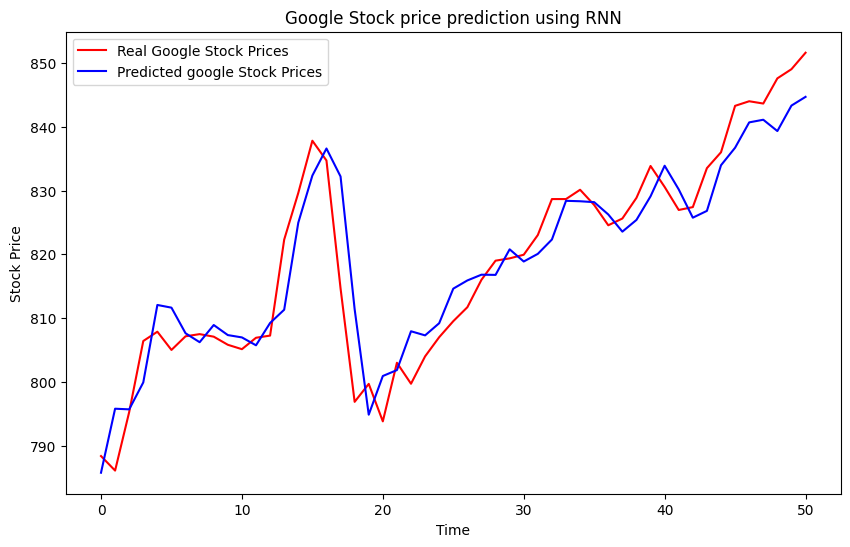

In [19]:
plt.figure(figsize=(10,6))

plt.plot(real_values,color='red',label='Real Google Stock Prices')
plt.plot(predicted_values,color='blue',label='Predicted google Stock Prices')

plt.title('Google Stock price prediction using RNN')

plt.xlabel('Time')
plt.ylabel('Stock Price')

plt.legend()
plt.show()